# Weekly Workflow — BBO Capstone

Slim notebook for each week: load data, fit surrogates, generate queries, format for portal.
Run cells in order. After receiving results, use **data_management.ipynb** to load and update, then return here for the next week.

## 1. Setup and load data

**Week 7 approach** (after Week 6: 3 new bests — F5, F6, F8; F2/F3 drifted; F1 faint signal at center):

- **F1**: Manual [0.55, 0.45] — probe near center after W6's 2.68e-09 (largest non-zero ever).
- **F2**: **GP** (noise=0.05), EI ξ=0.003, focus_radius=0.02 near [0.70, 0.934] — new point in best region (re-querying same point would learn nothing).
- **F3**: GP-ARD, EI ξ=0.0005, focus_radius=0.02 near W5 best (x2 sensitive; W6 at 0.365 regressed).
- **F4**: GP-ARD, EI ξ=0.0001, focus_radius=0.01 near W2 best (ultra-tight; W6 at 0.637 was 2nd-best).
- **F5**: Manual [0.999999, 0.999999, 0.999999, 0.999999] — stay at boundary (W6: 8662).
- **F6**: GP-ARD, EI ξ=0.001, focus_radius=0.02 near **W6 best** [0.218, 0.285, 0.442, 0.788, 0.030].
- **F7**: GP-ARD, EI ξ=0.003, focus_radius=0.03 near W3 best [0.070, 0.246, 0.464, 0.194, 0.366, 0.770].
- **F8**: SVR, EI ξ=0.005, focus_radius=0.015 near **W6 best** [0.116, 0.191, 0.115, 0.112, 0.876, 0.324, 0.116, 0.545].

Run the cells below to load functions and historical results, then edit the strategy dict in **Section 2** if needed and generate queries.

In [1]:
import sys
from pathlib import Path
# Allow imports from src when run from notebooks/ or from project root
root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))

import numpy as np
from src.data import FunctionData, DATA_DIR, initialize_all_weeks
from src.surrogates import GPSurrogate, SVMSurrogate, MLPSurrogate
from src.acquisition import optimize_acquisition_enhanced, optimize_acquisition_with_regional_focus
from src.utils import format_for_portal, plot_progress, display_competition_summary

np.random.seed(42)
print("✓ Imports ready")
# If you get ImportError for SVMSurrogate/MLPSurrogate: use Kernel → Restart, then run again (clears cached bytecode).

✓ Imports ready


In [2]:
# Load all 8 functions (from data/function_1 .. function_8)
functions = {i: FunctionData(i, data_dir=DATA_DIR) for i in range(1, 9)}
for i, f in functions.items():
    print(f"  {f}")
print("✓ Functions loaded")

  Function 1: 2D, 10 samples, best=0.000000
  Function 2: 2D, 10 samples, best=0.611205
  Function 3: 3D, 15 samples, best=-0.034835
  Function 4: 4D, 30 samples, best=-4.025542
  Function 5: 4D, 20 samples, best=1088.859618
  Function 6: 5D, 20 samples, best=-0.714265
  Function 7: 6D, 30 samples, best=1.364968
  Function 8: 8D, 40 samples, best=9.598482
✓ Functions loaded


In [ ]:
# Initialize with all historical weeks (from data/results/week_1, week_2, ...)
num_weeks = initialize_all_weeks(functions)
print(f"✓ Initialized with {num_weeks} weeks of results")

## 2. Week-specific strategies

Edit the strategy per function below. Then run the next cell to generate queries.

In [3]:
# Week 7 strategies (post W6: 3 new bests F5/F6/F8; F1/F2/F5 manual; tighter radii)
# Use "manual_query": np.array([...]) to bypass surrogate. Use "use_ard": True for GP-ARD.
CURRENT_WEEK = 7

# Reference points (best known per function after Week 6)
f1_probe = np.array([0.55, 0.45])  # probe near center after W6 faint signal
f2_focus = np.array([0.700, 0.934])  # best region; use GP with tight radius to get a new nearby point (not re-query)
f3_w5_best = np.array([0.384, 0.390, 0.467])
f4_w2_best = np.array([0.417, 0.409, 0.355, 0.427])
f5_upper = np.array([0.999999, 0.999999, 0.999999, 0.999999])
f6_w6_best = np.array([0.218, 0.285, 0.442, 0.788, 0.030])  # W6 new best
f7_w3_best = np.array([0.070, 0.246, 0.464, 0.194, 0.366, 0.770])
f8_w6_best = np.array([0.116, 0.191, 0.115, 0.112, 0.876, 0.324, 0.116, 0.545])  # W6 new best

strategies = {
    1: {"manual_query": f1_probe},
    2: {"surrogate": "gp", "gp_noise": 0.05, "acq_func": "ei", "xi": 0.003, "use_regional_focus": True, "focus_region": f2_focus, "focus_radius": 0.02, "n_random": 1500},
    3: {"surrogate": "gp", "use_ard": True, "acq_func": "ei", "xi": 0.0005, "use_regional_focus": True, "focus_region": f3_w5_best, "focus_radius": 0.02, "n_random": 1500},
    4: {"surrogate": "gp", "use_ard": True, "acq_func": "ei", "xi": 0.0001, "use_regional_focus": True, "focus_region": f4_w2_best, "focus_radius": 0.01, "expand_search": False, "n_random": 1500},
    5: {"manual_query": f5_upper},
    6: {"surrogate": "gp", "use_ard": True, "acq_func": "ei", "xi": 0.001, "use_regional_focus": True, "focus_region": f6_w6_best, "focus_radius": 0.02, "n_random": 1500},
    7: {"surrogate": "gp", "use_ard": True, "acq_func": "ei", "xi": 0.003, "use_regional_focus": True, "focus_region": f7_w3_best, "focus_radius": 0.03, "n_random": 1500},
    8: {"surrogate": "svr", "acq_func": "ei", "xi": 0.005, "use_regional_focus": True, "focus_region": f8_w6_best, "focus_radius": 0.015, "n_random": 1200},
}
print(f"✓ Strategies set for Week {CURRENT_WEEK}")

✓ Strategies set for Week 6


## 3. Generate queries

In [4]:
def _make_surrogate(surrogate_key: str, func_data, strategy: dict):
    key = surrogate_key.lower()
    if key == "gp":
        use_ard = strategy.get("use_ard", False)
        noise = strategy.get("gp_noise", 1e-5)
        return GPSurrogate(length_scale=0.5, optimize=True, noise=noise, use_ard=use_ard)
    if key == "svr":
        return SVMSurrogate(C=10.0, epsilon=0.1, n_bootstrap=20)
    if key == "mlp":
        return MLPSurrogate(hidden_sizes=(64, 32), dropout=0.1, n_mc_samples=50)
    return GPSurrogate(length_scale=0.5, optimize=True)

queries = {}
surrogates = {}

for func_id in range(1, 9):
    func_data = functions[func_id]
    s = strategies.get(func_id, {"acq_func": "ucb", "beta": 2.0})
    if "manual_query" in s:
        x = np.asarray(s["manual_query"], dtype=float)
        queries[func_id] = x
        surrogates[func_id] = None
        print(f"  F{func_id}: MANUAL → x = {np.array2string(x, precision=4)}")
        continue
    surrogate_key = s.get("surrogate", "gp")
    surrogate = _make_surrogate(surrogate_key, func_data, s)
    surrogate.fit(func_data.inputs, func_data.outputs)
    acq_func = s.get("acq_func", "ucb")
    acq_params = {k: v for k, v in s.items() if k in ("beta", "xi")}
    if s.get("use_regional_focus") and s.get("focus_region") is not None:
        x, mu, sigma = optimize_acquisition_with_regional_focus(
            surrogate, func_data, acq_func=acq_func,
            focus_region=s["focus_region"], focus_radius=s.get("focus_radius", 0.15),
            n_random=s.get("n_random", 1000), expand_search=s.get("expand_search", True),
            **acq_params
        )
    else:
        x, mu, sigma = optimize_acquisition_enhanced(
            surrogate, func_data, acq_func=acq_func,
            n_random=s.get("n_random", 1000), **acq_params
        )
    queries[func_id] = x
    surrogates[func_id] = surrogate
    print(f"  F{func_id}: {acq_func.upper()} → x = {np.array2string(x, precision=4)}")

print("✓ Queries generated")

  F1: MANUAL → x = [0.5 0.5]
  F2: EI → x = [0.74  0.974]
  F3: EI → x = [0.3868 0.3654 0.4621]


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


  F4: EI → x = [0.4309 0.4206 0.3636 0.4145]
  F5: MANUAL → x = [1. 1. 1. 1.]
  F6: EI → x = [0.218 0.285 0.442 0.788 0.03 ]


/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


  F7: EI → x = [0.03   0.286  0.4272 0.2064 0.3808 0.7542]
  F8: EI → x = [0.1156 0.1908 0.1154 0.1122 0.8759 0.3235 0.1165 0.5445]
✓ Queries generated


## 4. Format and submit

In [5]:
format_for_portal(queries, title=f"WEEK {CURRENT_WEEK} QUERIES — READY FOR SUBMISSION")

╔==============================================================================╗
║                    WEEK 6 QUERIES — READY FOR SUBMISSION                     ║
╠==============================================================================╣
║ Function 1: 0.500000-0.500000                                                ║
║ Function 2: 0.740000-0.974000                                                ║
║ Function 3: 0.386775-0.365388-0.462079                                       ║
║ Function 4: 0.430925-0.420569-0.363620-0.414510                              ║
║ Function 5: 0.999999-0.999999-0.999999-0.999999                              ║
║ Function 6: 0.218000-0.285000-0.442000-0.788000-0.030000                     ║
║ Function 7: 0.030000-0.286000-0.427159-0.206396-0.380818-0.754197            ║
║ Function 8: 0.115578-0.190816-0.115400-0.112172-0.875862-0.323507-0.116467-0.544547 ║
╚==============================================================================╝

✓ Copy the formatted

## 5. Optional: view progress

COMPETITION SUMMARY
Total weekly submissions: 0
Best values by function:
--------------------------------------------------------------------------------
Function 1 (2D): 0.000000 (+0.000000, 10 samples)
Function 2 (2D): 0.611205 (+0.072209, 10 samples)
Function 3 (3D): -0.034835 (+0.077287, 15 samples)
Function 4 (4D): -4.025542 (+18.082746, 30 samples)
Function 5 (4D): 1088.859618 (+1024.416178, 20 samples)
Function 6 (5D): -0.714265 (+0.000000, 20 samples)
Function 7 (6D): 1.364968 (+0.760536, 30 samples)
Function 8 (8D): 9.598482 (+2.199761, 40 samples)


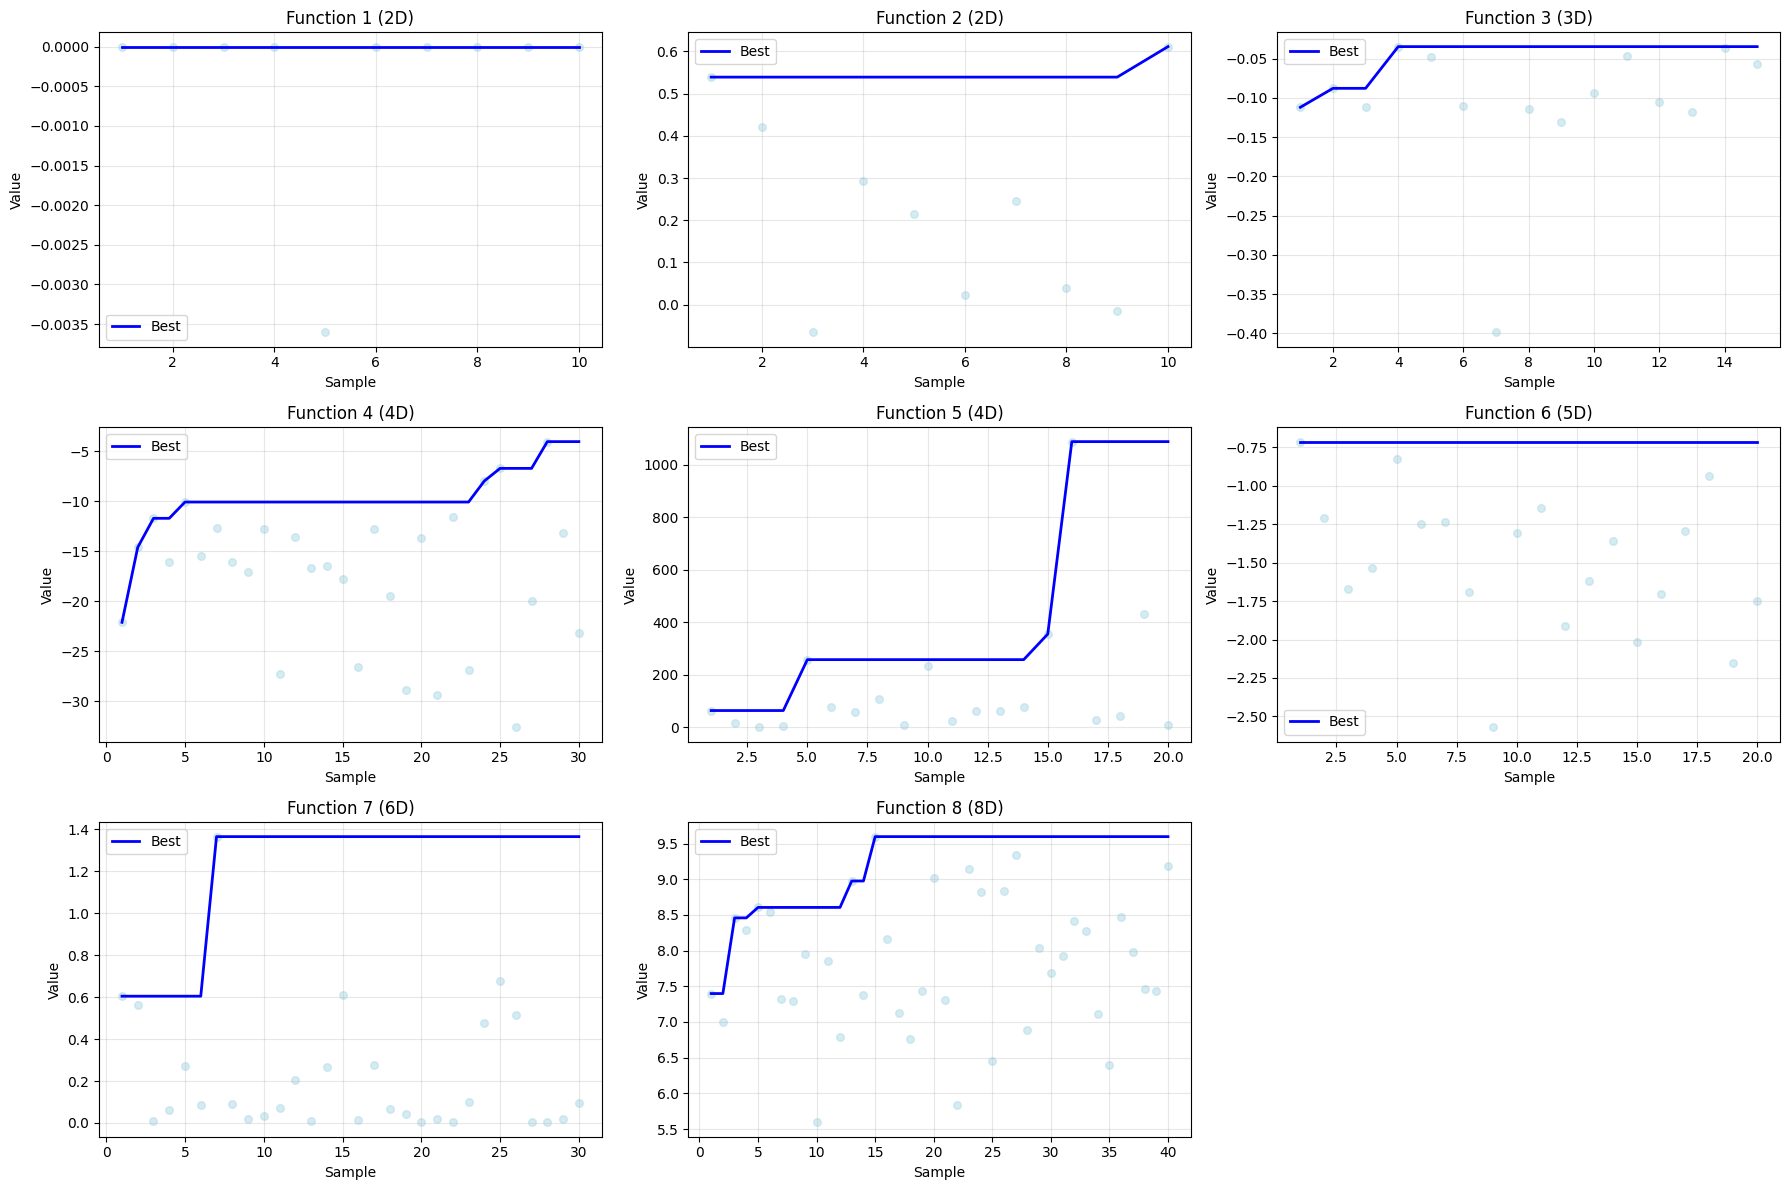

In [6]:
display_competition_summary(functions)
plot_progress(functions)